In [3]:

# Projet 2 — Spectral analysis of real data (CANDHIS buoy, La Palue)


In [4]:

# On charge les donées, on les nettoies un petit peu
# Puis on comprend comment est construit ce tableau et enfin on va aller chercher 
# les données interessantes (dateHeure, H0, T)


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/Candhis_02914_2009_arch.csv', sep=';', parse_dates=['DateHeure']) # charger le fichier de la bouée

df = df.replace(999.999, np.nan) # Les valeurs manquantes sont marquées 999.999, ont les remplaces pas NaN

print(df.shape)        # Nombre de lignes et colonnes
print(df.head())       # Premières lignes
print(df.columns.tolist())  # liste des colonnes

(2102, 73)
            DateHeure  H13D  H110D  HMAXD  HSIGMA  HRMSD  H2%D  TH13D  TH110D  \
0 2009-11-09 14:30:00  1.64   2.15   2.46    1.72   1.16  2.41   14.0    14.0   
1 2009-11-09 15:00:00   NaN    NaN    NaN     NaN    NaN   NaN    NaN     NaN   
2 2009-11-09 15:30:00  1.92   2.50   3.17    2.10   1.37  2.75   11.1    11.2   
3 2009-11-09 16:00:00  1.66   2.09   3.13    1.76   1.18  2.41   10.6    10.5   
4 2009-11-09 16:30:00  1.84   2.21   2.52    1.96   1.32  2.32   10.6    10.8   

   TAVGD  ...  HM0_S4  TP_S4  T02_S4  TE_S4  EPS2_S4  KAPA_S4  THETAP_S4  \
0   12.2  ...     NaN    NaN     NaN    NaN      NaN      NaN        NaN   
1    NaN  ...     NaN    NaN     NaN    NaN      NaN      NaN        NaN   
2    9.4  ...     NaN    NaN     NaN    NaN      NaN      NaN        NaN   
3    8.5  ...     NaN    NaN     NaN    NaN      NaN      NaN        NaN   
4    9.0  ...     NaN    NaN     NaN    NaN      NaN      NaN        NaN   

   THETAM_S4  SIGMAP_S4  SIGMAM_S4  
0       

In [6]:

# Gardons seulement datHeure, H13D et TH13D
# Ici on a H13 pour H1/3, c'est la hauteur significative enregistrée par la bouée.
# Ex : sur 100 vagues en 30 min la bouée va prendre les 33 + grande et fait la moyenne de ces vagues là


In [7]:
data = df[['DateHeure', 'H13D', 'TH13D']].copy()
data = data.dropna()  # supprime les lignes avec NaN
data = data.rename(columns={
    'H13D' : 'H',   # hauteur significative (m) c'est H0 dans projet 1
    'TH13D': 'T'    # période (s)
})

print(f"Nombre de mesures valides : {len(data)}")
print(f"Période couverte : {data['DateHeure'].min()} → {data['DateHeure'].max()}")
print(data.describe())  # statistiques de base

Nombre de mesures valides : 2101
Période couverte : 2009-11-09 14:30:00 → 2009-12-23 11:30:00
                        DateHeure            H            T
count                        2101  2101.000000  2101.000000
mean   2009-12-01 12:58:41.180390     3.162089     9.267825
min           2009-11-09 14:30:00     0.500000     3.900000
25%           2009-11-20 14:00:00     1.800000     7.600000
50%           2009-12-01 12:30:00     3.150000     9.500000
75%           2009-12-12 12:00:00     4.410000    10.800000
max           2009-12-23 11:30:00     8.090000    16.600000
std                           NaN     1.623960     2.278124


In [8]:

# Visualisions mtn ces donées sur un graph


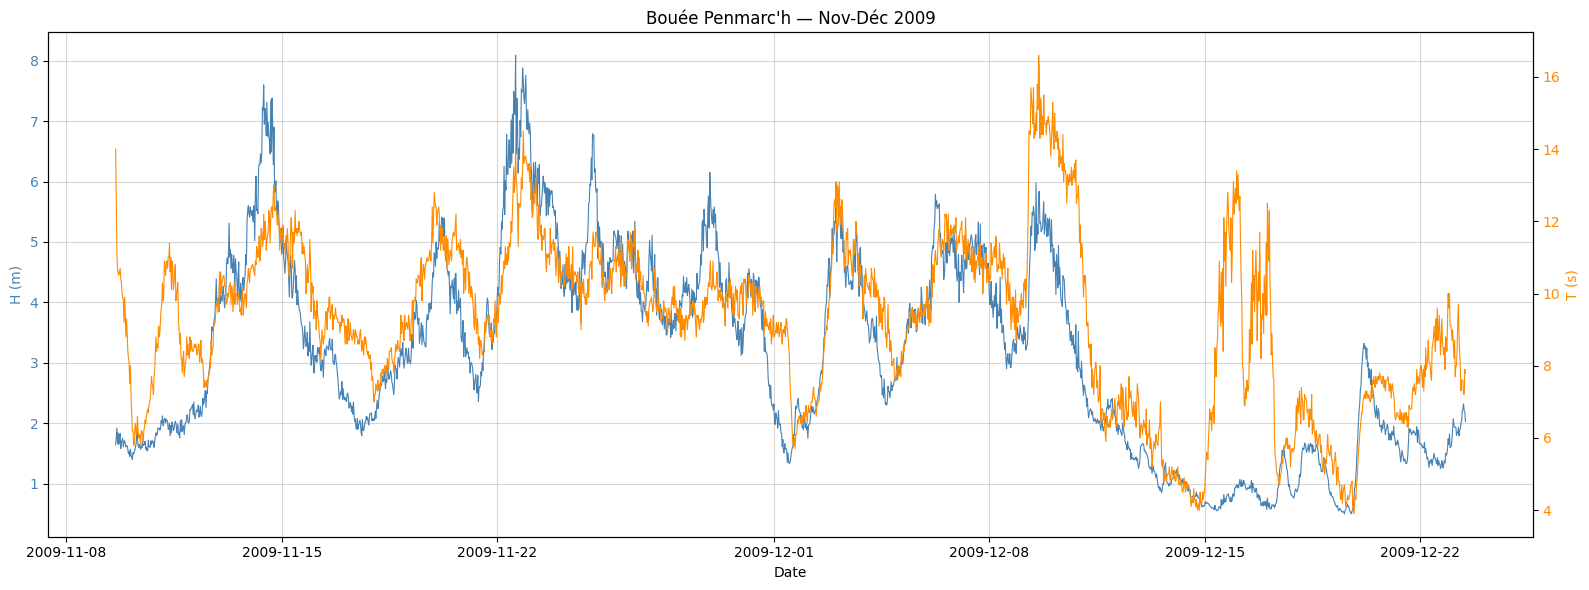

In [14]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(16, 6))

# Hauteur 
color = 'steelblue'
ax1.set_xlabel('Date')
ax1.set_ylabel('H (m)', color = color)
line1 = ax1.plot(data['DateHeure'], data['H'], color=color, linewidth=0.8, label='Hauteur (H)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(alpha=0.5)

# Période
ax2 = ax1.twinx()
color = 'darkorange'
ax2.set_ylabel('T (s)', color=color)
line2 = ax2.plot(data['DateHeure'], data['T'], color=color, linewidth=0.8, label='Période (T)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Bouée Penmarc\'h — Nov-Déc 2009')
plt.tight_layout()
plt.show()